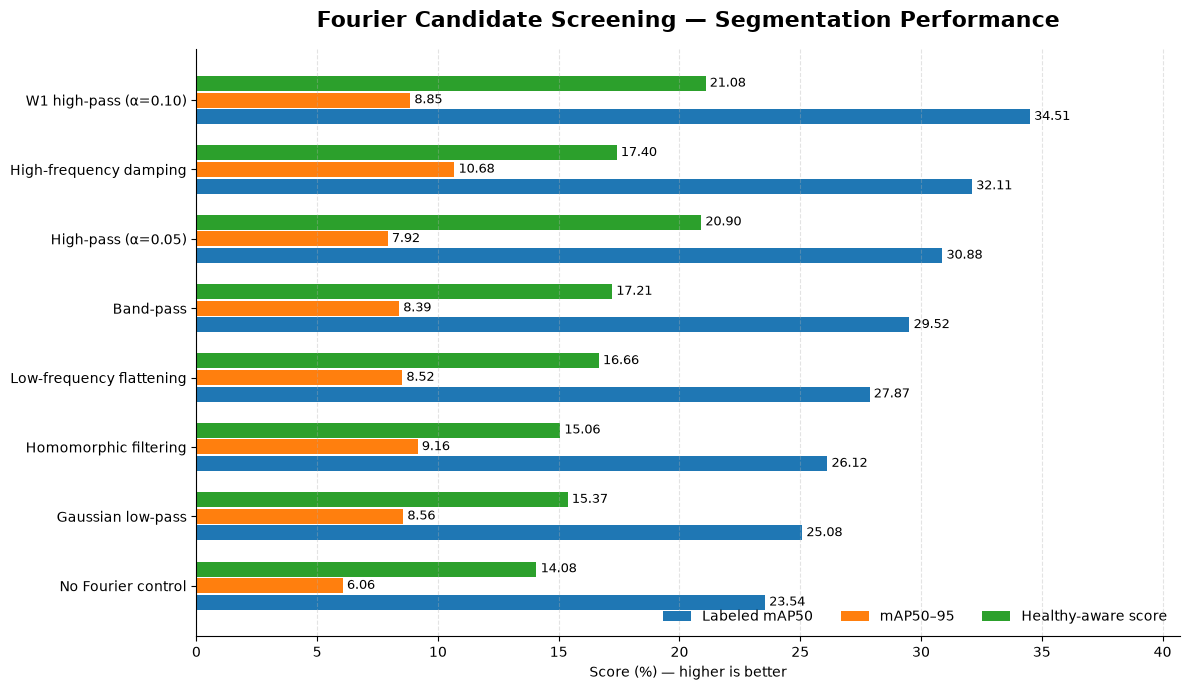

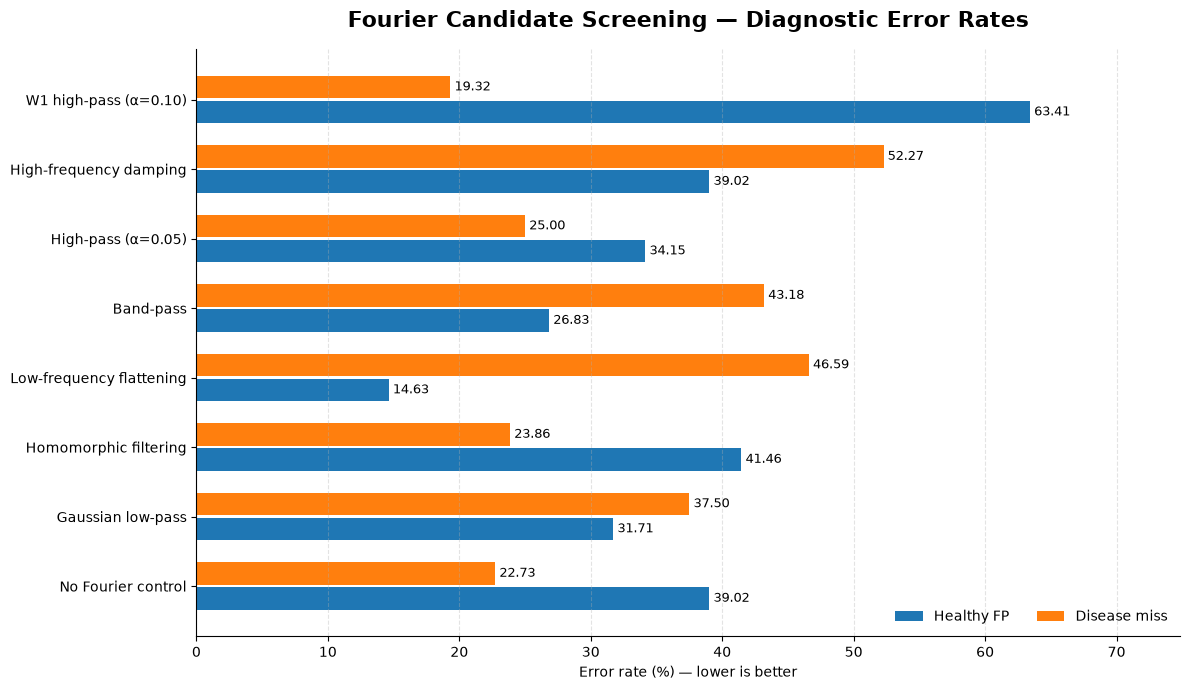

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ---------------------------------------------------------
# Data
# ---------------------------------------------------------
data = {
    "Configuration": [
        "No Fourier control",
        "High-pass (α=0.05)",
        "W1 high-pass (α=0.10)",
        "High-frequency damping",
        "Band-pass",
        "Low-frequency flattening",
        "Homomorphic filtering",
        "Gaussian low-pass",
    ],
    "Labeled mAP50": [
        23.54, 30.88, 34.51, 32.11,
        29.52, 27.87, 26.12, 25.08
    ],
    "mAP50–95": [
        6.06, 7.92, 8.85, 10.68,
        8.39, 8.52, 9.16, 8.56
    ],
    "Healthy FP": [
        39.02, 34.15, 63.41, 39.02,
        26.83, 14.63, 41.46, 31.71
    ],
    "Disease miss": [
        22.73, 25.00, 19.32, 52.27,
        43.18, 46.59, 23.86, 37.50
    ],
    "Healthy-aware score": [
        14.08, 20.90, 21.08, 17.40,
        17.21, 16.66, 15.06, 15.37
    ],
}

df = pd.DataFrame(data)

# Sort consistently across both charts.
df = df.sort_values("Labeled mAP50", ascending=True).reset_index(drop=True)


# ---------------------------------------------------------
# Reusable grouped horizontal-bar function
# ---------------------------------------------------------
def grouped_horizontal_chart(
    dataframe: pd.DataFrame,
    metrics: list[str],
    title: str,
    xlabel: str,
    output_path: str,
) -> None:
    configurations = dataframe["Configuration"].to_numpy()
    y = np.arange(len(configurations))

    group_height = 0.72
    bar_height = group_height / len(metrics)

    fig, ax = plt.subplots(figsize=(12, 7))

    for index, metric in enumerate(metrics):
        offset = (
            index - (len(metrics) - 1) / 2
        ) * bar_height

        bars = ax.barh(
            y + offset,
            dataframe[metric],
            height=bar_height * 0.90,
            label=metric,
        )

        ax.bar_label(
            bars,
            labels=[f"{value:.2f}" for value in dataframe[metric]],
            padding=3,
            fontsize=9,
        )

    ax.set_yticks(y)
    ax.set_yticklabels(configurations)
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=16, fontweight="bold", pad=16)

    ax.grid(axis="x", linestyle="--", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        loc="lower right",
        frameon=False,
        ncol=len(metrics),
    )

    # Extra room for value labels.
    maximum = dataframe[metrics].to_numpy().max()
    ax.set_xlim(0, maximum * 1.18)

    fig.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


# ---------------------------------------------------------
# Chart 1: Higher is better
# ---------------------------------------------------------
grouped_horizontal_chart(
    dataframe=df,
    metrics=[
        "Labeled mAP50",
        "mAP50–95",
        "Healthy-aware score",
    ],
    title="Fourier Candidate Screening — Segmentation Performance",
    xlabel="Score (%) — higher is better",
    output_path="fourier_performance_metrics.png",
)


# ---------------------------------------------------------
# Chart 2: Lower is better
# ---------------------------------------------------------
grouped_horizontal_chart(
    dataframe=df,
    metrics=[
        "Healthy FP",
        "Disease miss",
    ],
    title="Fourier Candidate Screening — Diagnostic Error Rates",
    xlabel="Error rate (%) — lower is better",
    output_path="fourier_error_metrics.png",
)

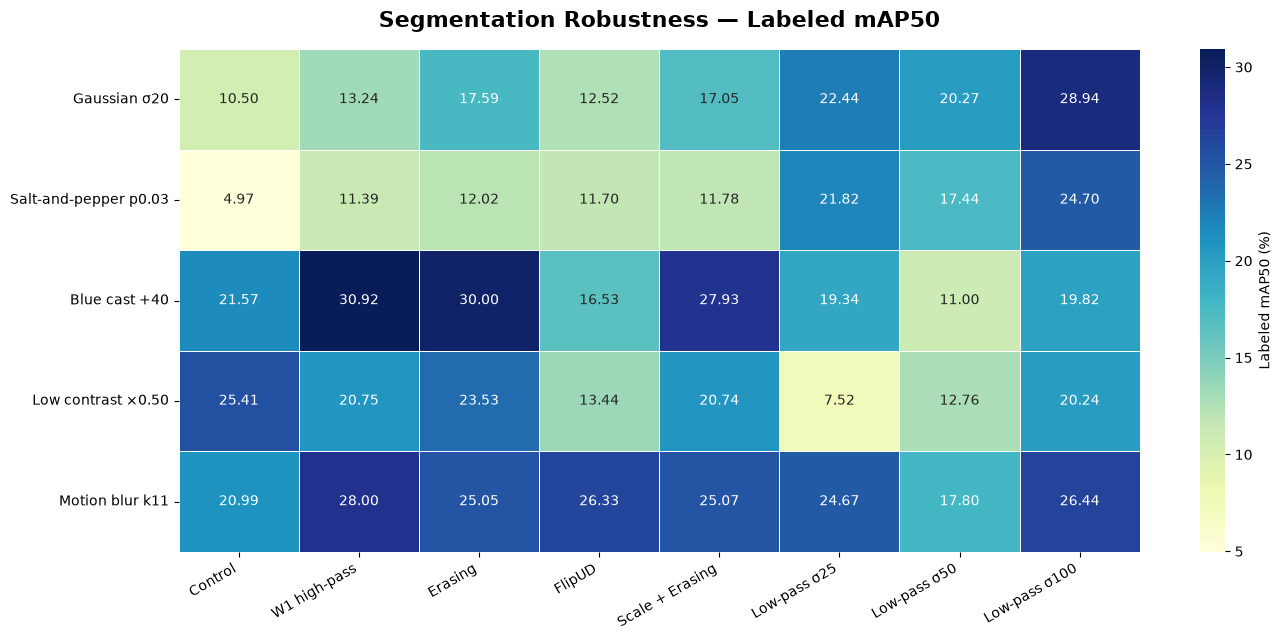

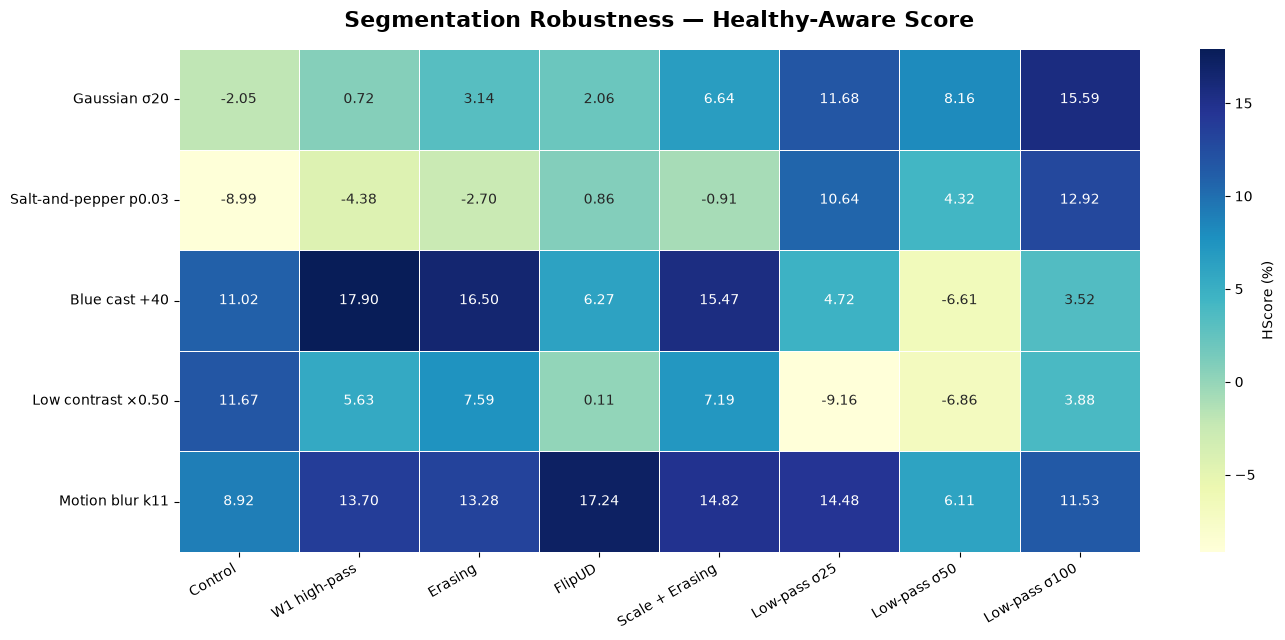

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


data = [
    # Noise, Configuration, Labeled mAP50, HScore, Healthy FP
    ("Gaussian σ20", "Control", 10.50, -2.05, 48.78),
    ("Gaussian σ20", "W1 high-pass", 13.24, 0.72, 53.66),
    ("Gaussian σ20", "Erasing", 17.59, 3.14, 19.51),
    ("Gaussian σ20", "FlipUD", 12.52, 2.06, 26.83),
    ("Gaussian σ20", "Scale + Erasing", 17.05, 6.64, 53.66),
    ("Gaussian σ20", "Low-pass σ25", 22.44, 11.68, 29.27),
    ("Gaussian σ20", "Low-pass σ50", 20.27, 8.16, 29.27),
    ("Gaussian σ20", "Low-pass σ100", 28.94, 15.59, 26.83),

    ("Salt-and-pepper p0.03", "Control", 4.97, -8.99, 48.78),
    ("Salt-and-pepper p0.03", "W1 high-pass", 11.39, -4.38, 78.05),
    ("Salt-and-pepper p0.03", "Erasing", 12.02, -2.70, 9.76),
    ("Salt-and-pepper p0.03", "FlipUD", 11.70, 0.86, 34.15),
    ("Salt-and-pepper p0.03", "Scale + Erasing", 11.78, -0.91, 56.10),
    ("Salt-and-pepper p0.03", "Low-pass σ25", 21.82, 10.64, 29.27),
    ("Salt-and-pepper p0.03", "Low-pass σ50", 17.44, 4.32, 29.27),
    ("Salt-and-pepper p0.03", "Low-pass σ100", 24.70, 12.92, 19.51),

    ("Blue cast +40", "Control", 21.57, 11.02, 29.27),
    ("Blue cast +40", "W1 high-pass", 30.92, 17.90, 48.78),
    ("Blue cast +40", "Erasing", 30.00, 16.50, 19.51),
    ("Blue cast +40", "FlipUD", 16.53, 6.27, 14.63),
    ("Blue cast +40", "Scale + Erasing", 27.93, 15.47, 21.95),
    ("Blue cast +40", "Low-pass σ25", 19.34, 4.72, 26.83),
    ("Blue cast +40", "Low-pass σ50", 11.00, -6.61, 7.32),
    ("Blue cast +40", "Low-pass σ100", 19.82, 3.52, 21.95),

    ("Low contrast ×0.50", "Control", 25.41, 11.67, 14.63),
    ("Low contrast ×0.50", "W1 high-pass", 20.75, 5.63, 19.51),
    ("Low contrast ×0.50", "Erasing", 23.53, 7.59, 12.20),
    ("Low contrast ×0.50", "FlipUD", 13.44, 0.11, 9.76),
    ("Low contrast ×0.50", "Scale + Erasing", 20.74, 7.19, 2.44),
    ("Low contrast ×0.50", "Low-pass σ25", 7.52, -9.16, 0.00),
    ("Low contrast ×0.50", "Low-pass σ50", 12.76, -6.86, 4.88),
    ("Low contrast ×0.50", "Low-pass σ100", 20.24, 3.88, 19.51),

    ("Motion blur k11", "Control", 20.99, 8.92, 39.02),
    ("Motion blur k11", "W1 high-pass", 28.00, 13.70, 75.61),
    ("Motion blur k11", "Erasing", 25.05, 13.28, 26.83),
    ("Motion blur k11", "FlipUD", 26.33, 17.24, 31.71),
    ("Motion blur k11", "Scale + Erasing", 25.07, 14.82, 36.59),
    ("Motion blur k11", "Low-pass σ25", 24.67, 14.48, 31.71),
    ("Motion blur k11", "Low-pass σ50", 17.80, 6.11, 31.71),
    ("Motion blur k11", "Low-pass σ100", 26.44, 11.53, 31.71),
]

df = pd.DataFrame(
    data,
    columns=[
        "Noise",
        "Configuration",
        "Labeled mAP50",
        "HScore",
        "Healthy FP",
    ],
)

configuration_order = [
    "Control",
    "W1 high-pass",
    "Erasing",
    "FlipUD",
    "Scale + Erasing",
    "Low-pass σ25",
    "Low-pass σ50",
    "Low-pass σ100",
]

noise_order = [
    "Gaussian σ20",
    "Salt-and-pepper p0.03",
    "Blue cast +40",
    "Low contrast ×0.50",
    "Motion blur k11",
]


def create_heatmap(metric: str, title: str, output_name: str) -> None:
    matrix = df.pivot(
        index="Noise",
        columns="Configuration",
        values=metric,
    )

    matrix = matrix.reindex(
        index=noise_order,
        columns=configuration_order,
    )

    plt.figure(figsize=(14, 6.5))

    sns.heatmap(
        matrix,
        annot=True,
        fmt=".2f",
        linewidths=0.6,
        linecolor="white",
        cmap="YlGnBu",
        cbar_kws={"label": f"{metric} (%)"},
    )

    plt.title(title, fontsize=16, fontweight="bold", pad=16)
    plt.xlabel("")
    plt.ylabel("")
    plt.xticks(rotation=30, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.savefig(output_name, dpi=300, bbox_inches="tight")
    plt.show()


create_heatmap(
    metric="Labeled mAP50",
    title="Segmentation Robustness — Labeled mAP50",
    output_name="robustness_labeled_map50.png",
)

create_heatmap(
    metric="HScore",
    title="Segmentation Robustness — Healthy-Aware Score",
    output_name="robustness_hscore.png",
)